# Greater Paris observed mobility motifs

This notebook classifies every observed user-day in the full Greater Paris visitation panel with fastmob's canonical daily mobility motifs. It then describes motif prevalence, the number of motifs people use, and how stable each person's motif is on weekdays versus weekends.

The headline figures are unweighted descriptions of observed people and days. Survey-weighted motif prevalence is included as a sensitivity check.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from fastmob import discover_daily_motifs_from_agents

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)

NOTEBOOK_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'notebooks' / '00_ile_de_france_exploration',
]
NOTEBOOK_DIR = next(
    (path for path in NOTEBOOK_DIR_CANDIDATES if (path / '02_mtus_exploration.ipynb').exists()),
    Path.cwd(),
)
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == '00_ile_de_france_exploration' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OBSERVED_PATH = PROJECT_ROOT / 'data' / 'gparis' / 'gparis_visitation_full_data.parquet'
assert OBSERVED_PATH.exists(), f'Observed visitation file not found: {OBSERVED_PATH}'
print(f'Project root: {PROJECT_ROOT.resolve()}')
print(f'Observed input: {OBSERVED_PATH.resolve()}')

Project root: /home/gustavo/citybehavex
Observed input: /mnt/toshiba/gustavo/citybehavex_data/gparis/gparis_visitation_full_data.parquet


## Load and validate observed visits

`area` is the observed location identifier. The original `HOME` purposes and visit durations are retained so fastmob can identify each user's primary home before canonicalizing the daily graph.

In [2]:
REQUIRED_COLUMNS = {
    'user_id', 'area', 'purpose', 'start_timestamp', 'end_timestamp', 'duration_minutes', 'weight'
}

visits = pd.read_parquet(OBSERVED_PATH).copy()
missing_columns = REQUIRED_COLUMNS - set(visits.columns)
assert not missing_columns, f'Missing required columns: {sorted(missing_columns)}'

visits['start_timestamp'] = pd.to_datetime(visits['start_timestamp'], errors='coerce')
visits['end_timestamp'] = pd.to_datetime(visits['end_timestamp'], errors='coerce')
visits['duration_minutes'] = pd.to_numeric(visits['duration_minutes'], errors='coerce')
visits['weight'] = pd.to_numeric(visits['weight'], errors='coerce')
visits = visits.dropna(subset=['user_id', 'area', 'purpose', 'start_timestamp', 'end_timestamp'])
visits = visits[visits['end_timestamp'] >= visits['start_timestamp']].copy()
assert not visits.empty, 'No valid observed visits remain after validation.'

visits['date'] = visits['start_timestamp'].dt.normalize()
visits['day_group'] = np.where(visits['start_timestamp'].dt.dayofweek >= 5, 'Weekend', 'Weekday')
visits['day_group'] = pd.Categorical(visits['day_group'], categories=['Weekday', 'Weekend'], ordered=True)

coverage = pd.Series({
    'valid visits': len(visits),
    'people': visits['user_id'].nunique(),
    'observed user-days': visits[['user_id', 'date']].drop_duplicates().shape[0],
    'first date': visits['date'].min().date(),
    'last date': visits['date'].max().date(),
    'HOME visits': int((visits['purpose'] == 'HOME').sum()),
})
display(coverage.rename_axis('metric').reset_index(name='value'))
display(visits['purpose'].value_counts().rename_axis('purpose').reset_index(name='visits'))

,metric,value
0,valid visits,67597
1,people,3324
2,observed user-days,18802
3,first date,2022-09-12
4,last date,2023-05-19
5,HOME visits,26020


,purpose,visits
0,HOME,26020
1,WORK,13296
2,OTHER,9501
3,PURCHASE,9223
4,LEISURE,6487
5,HEALTH,1611
6,STUDIES,1459


## Discover a canonical motif for each user-day

Fastmob builds each directed daily mobility graph in parallel, forces the primary home to the canonical home node, and returns the canonical graph ID with its number of nodes and edges.

In [3]:
daily_motifs, motif_distribution = discover_daily_motifs_from_agents(
    visits,
    user_id_col='user_id',
    location_id_col='area',
    purpose_col='purpose',
    timestamp_col='start_timestamp',
    end_timestamp_col='end_timestamp',
    duration_col='duration_minutes',
)
daily_motifs = daily_motifs.copy()
daily_motifs['date'] = pd.to_datetime(daily_motifs['date'])
daily_motifs['day_group'] = pd.Categorical(
    np.where(daily_motifs['date'].dt.dayofweek >= 5, 'Weekend', 'Weekday'),
    categories=['Weekday', 'Weekend'],
    ordered=True,
)

input_user_days = visits[['user_id', 'date']].drop_duplicates()
assert not daily_motifs.duplicated(['user_id', 'date']).any(), 'Fastmob returned duplicate user-day motifs.'
skipped_user_days = input_user_days.merge(
    daily_motifs[['user_id', 'date']], on=['user_id', 'date'], how='left', indicator=True
).query("_merge == 'left_only'").drop(columns='_merge')
assert len(daily_motifs) + len(skipped_user_days) == len(input_user_days)
assert daily_motifs['motif_id'].notna().all(), 'Fastmob returned a missing motif ID.'

day_weights = (
    visits.groupby(['user_id', 'date'], as_index=False)['weight']
    .first()
    .rename(columns={'weight': 'day_weight'})
)
daily_motifs = daily_motifs.merge(day_weights, on=['user_id', 'date'], how='left', validate='one_to_one')
daily_motifs['motif_label'] = daily_motifs.apply(
    lambda row: f"{int(row['motif_id'])} ({int(row['num_nodes'])} nodes, {int(row['num_edges'])} edges)",
    axis=1,
)

print(f'Classified user-days: {len(daily_motifs):,} of {len(input_user_days):,}')
print(f'Skipped non-classifiable user-days: {len(skipped_user_days):,}')
print(f'Distinct canonical motifs: {daily_motifs["motif_id"].nunique():,}')
if not skipped_user_days.empty:
    display(skipped_user_days.sort_values(['user_id', 'date']).head(20))
display(daily_motifs.head())

Classified user-days: 18,798 of 18,802
Skipped non-classifiable user-days: 4
Distinct canonical motifs: 157


,user_id,date
18643,16_3943,2023-04-17
5834,42_0078,2022-10-20
11852,50_1632,2022-12-15
12491,5_2433,2023-01-30


,user_id,motif_id,num_nodes,num_edges,date,day_group,day_weight,motif_label
0,10_2978,274877933584,4,4,2023-03-15,Weekday,235.905683,"274877933584 (4 nodes, 4 edges)"
1,10_2978,274877933592,4,5,2023-03-16,Weekday,218.345882,"274877933592 (4 nodes, 5 edges)"
2,10_2978,274877923864,4,4,2023-03-17,Weekday,237.220279,"274877923864 (4 nodes, 4 edges)"
3,10_2980,206158430344,3,2,2023-03-13,Weekday,235.626361,"206158430344 (3 nodes, 2 edges)"
4,10_2980,137438953478,2,2,2023-03-14,Weekday,237.524429,"137438953478 (2 nodes, 2 edges)"


## Which motifs are most common?

The plot is unweighted: each observed user-day counts once. The table compares those shares with survey-weighted shares, so a large difference is visible rather than silently changing the headline population. Canonical IDs encode graph topology; node and edge counts provide a compact structural cue.

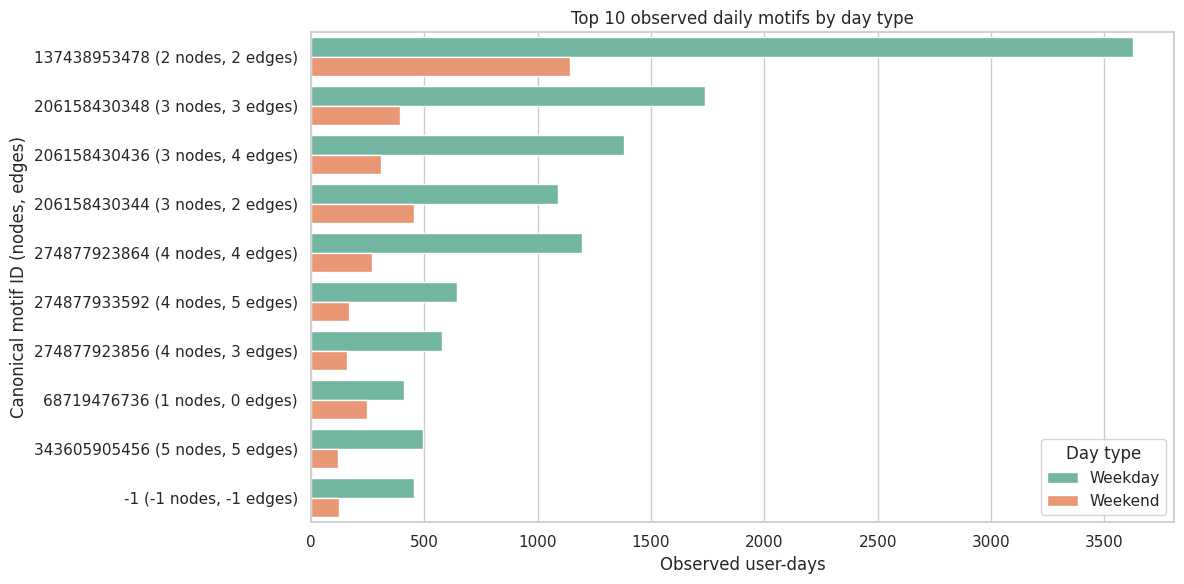

,motif_label,observed_days,unweighted %,weighted %
2,"137438953478 (2 nodes, 2 edges)",4770,25.375040,26.680939
4,"206158430348 (3 nodes, 3 edges)",2132,11.341632,10.807185
8,"206158430436 (3 nodes, 4 edges)",1692,9.000958,9.534594
3,"206158430344 (3 nodes, 2 edges)",1543,8.208320,8.178134
10,"274877923864 (4 nodes, 4 edges)",1465,7.793382,7.695126
20,"274877933592 (4 nodes, 5 edges)",810,4.308969,3.972724
9,"274877923856 (4 nodes, 3 edges)",733,3.899351,3.656741
156,"68719476736 (1 nodes, 0 edges)",659,3.505692,3.369114
34,"343605905456 (5 nodes, 5 edges)",614,3.266305,3.085661
0,"-1 (-1 nodes, -1 edges)",579,3.080115,3.199147


In [4]:
TOP_N_MOTIFS = 10
top_motif_ids = daily_motifs['motif_id'].value_counts().head(TOP_N_MOTIFS).index
top_motifs = daily_motifs[daily_motifs['motif_id'].isin(top_motif_ids)].copy()
motif_order = (
    top_motifs['motif_label'].value_counts().index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(
    data=top_motifs, y='motif_label', hue='day_group', order=motif_order,
    hue_order=['Weekday', 'Weekend'], palette='Set2', ax=ax,
)
ax.set_title(f'Top {TOP_N_MOTIFS} observed daily motifs by day type')
ax.set_xlabel('Observed user-days')
ax.set_ylabel('Canonical motif ID (nodes, edges)')
ax.legend(title='Day type')
plt.tight_layout()
plt.show()

valid_weights = daily_motifs['day_weight'].where(daily_motifs['day_weight'] > 0)
weighted_motifs = daily_motifs.assign(valid_weight=valid_weights).groupby('motif_label', as_index=False).agg(
    observed_days=('motif_id', 'size'),
    unweighted_share=('motif_id', lambda values: len(values) / len(daily_motifs)),
    weighted_days=('valid_weight', 'sum'),
)
weighted_motifs['weighted_share'] = weighted_motifs['weighted_days'] / weighted_motifs['weighted_days'].sum()
weighted_sensitivity = weighted_motifs[weighted_motifs['motif_label'].isin(motif_order)].copy()
weighted_sensitivity['unweighted_share'] *= 100
weighted_sensitivity['weighted_share'] *= 100
display(
    weighted_sensitivity.sort_values('observed_days', ascending=False)[
        ['motif_label', 'observed_days', 'unweighted_share', 'weighted_share']
    ].rename(columns={'unweighted_share': 'unweighted %', 'weighted_share': 'weighted %'})
)

## How many different motifs does each person use?

This is a within-person diversity measure: the number of distinct fastmob motifs seen across the person's available observed days. It is shown separately for all days, weekdays, and weekends; it is not adjusted for unequal numbers of observed days.

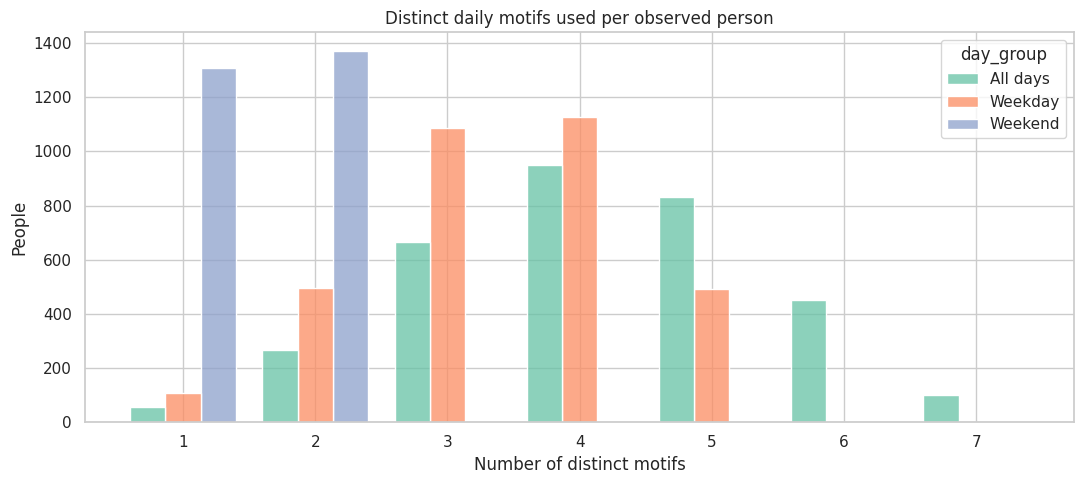

,count,mean,std,min,25%,50%,75%,max
day_group,,,,,,,,
All days,3320.0,4.20,1.30,1.0,3.0,4.0,5.0,7.0
Weekday,3315.0,3.42,1.02,1.0,3.0,3.0,4.0,6.0
Weekend,2681.0,1.51,0.50,1.0,1.0,2.0,2.0,3.0


In [5]:
all_diversity = daily_motifs.groupby('user_id', as_index=False).agg(
    distinct_motifs=('motif_id', 'nunique'), observed_days=('date', 'size')
)
all_diversity['day_group'] = 'All days'
group_diversity = daily_motifs.groupby(['user_id', 'day_group'], observed=True, as_index=False).agg(
    distinct_motifs=('motif_id', 'nunique'), observed_days=('date', 'size')
)
group_diversity['day_group'] = group_diversity['day_group'].astype(str)
diversity = pd.concat([all_diversity, group_diversity], ignore_index=True)
diversity['day_group'] = pd.Categorical(
    diversity['day_group'], categories=['All days', 'Weekday', 'Weekend'], ordered=True
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(
    data=diversity, x='distinct_motifs', hue='day_group', discrete=True,
    multiple='dodge', shrink=0.8, palette='Set2', ax=ax,
)
ax.set_title('Distinct daily motifs used per observed person')
ax.set_xlabel('Number of distinct motifs')
ax.set_ylabel('People')
plt.tight_layout()
plt.show()

display(diversity.groupby('day_group', observed=True)['distinct_motifs'].describe().round(2))

## Are motif signatures more regular on weekdays or weekends?

A person's regularity is the fraction of their available days in a group that use their most frequent motif. For a meaningful comparison, this section retains only people observed on at least two weekdays and at least two weekend days. A value of 1 means all observed days in that group had the same motif.

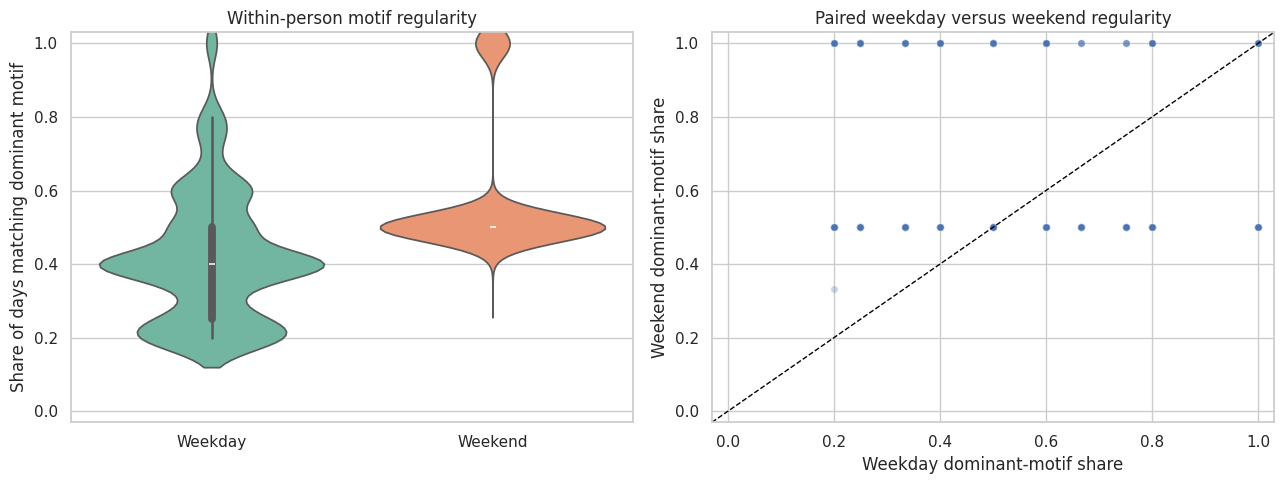

People eligible for paired comparison: 1,569
Mean weekday regularity: 41.7%
Mean weekend regularity: 56.6%
Mean weekend minus weekday difference: +14.9%


In [6]:
motif_counts = daily_motifs.groupby(['user_id', 'day_group', 'motif_id'], observed=True).size().rename('motif_days').reset_index()
regularity = motif_counts.groupby(['user_id', 'day_group'], observed=True, as_index=False).agg(
    observed_days=('motif_days', 'sum'),
    dominant_motif_days=('motif_days', 'max'),
)
regularity['dominant_motif_share'] = regularity['dominant_motif_days'] / regularity['observed_days']
eligible_regularity = regularity[regularity['observed_days'] >= 2].copy()
paired_regularity = eligible_regularity.pivot(
    index='user_id', columns='day_group', values='dominant_motif_share'
).dropna(subset=['Weekday', 'Weekend']).reset_index()
assert paired_regularity[['Weekday', 'Weekend']].ge(0).all().all()
assert paired_regularity[['Weekday', 'Weekend']].le(1).all().all()

regularity_long = paired_regularity.melt(
    id_vars='user_id', value_vars=['Weekday', 'Weekend'],
    var_name='day_group', value_name='dominant_motif_share',
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(
    data=regularity_long, x='day_group', y='dominant_motif_share', hue='day_group',
    order=['Weekday', 'Weekend'], palette='Set2', inner='box', legend=False, ax=axes[0],
)
axes[0].set_title('Within-person motif regularity')
axes[0].set_xlabel('')
axes[0].set_ylabel('Share of days matching dominant motif')
axes[0].set_ylim(-0.03, 1.03)

sns.scatterplot(data=paired_regularity, x='Weekday', y='Weekend', alpha=0.28, s=28, color='#4C72B0', ax=axes[1])
axes[1].axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Paired weekday versus weekend regularity')
axes[1].set_xlim(-0.03, 1.03)
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel('Weekday dominant-motif share')
axes[1].set_ylabel('Weekend dominant-motif share')
plt.tight_layout()
plt.show()

weekday_mean = paired_regularity['Weekday'].mean()
weekend_mean = paired_regularity['Weekend'].mean()
print(f'People eligible for paired comparison: {len(paired_regularity):,}')
print(f'Mean weekday regularity: {weekday_mean:.1%}')
print(f'Mean weekend regularity: {weekend_mean:.1%}')
print(f'Mean weekend minus weekday difference: {(weekend_mean - weekday_mean):+.1%}')

## Reading the results

Use the first plot to identify the dominant daily movement structures and whether their observed prevalence changes by day type. Use the diversity histogram to distinguish people with one recurring structure from people with several. Finally, compare the two regularity distributions and the paired scatter: points above the diagonal are more regular on weekends, while points below it are more regular on weekdays. These are descriptive results for the observed panel; they do not establish population-level differences or causal effects.